# Data Finding & Preprocessing

### Data Finding and Problems
Eight different datasets were utilized to formulate a single dataset. All the datasets were available on the kaggle:
* https://www.kaggle.com/datasets/ankan1998/weapon-detection-dataset
* https://www.kaggle.com/datasets/simuletic/cctv-weapon-dataset
* https://www.kaggle.com/datasets/trainingdatapro/people-with-guns-segmentation-and-detection
* https://www.kaggle.com/datasets/mehmetcubukcu/weapon-detection
* https://www.kaggle.com/datasets/anbumalar1991/fight-dataset
* https://www.kaggle.com/code/kirollosashraf/human-action-recognition-har
* https://www.kaggle.com/datasets/simuletic/cctv-knife-detection-dataset
* https://www.kaggle.com/datasets/shank885/knife-dataset

These datasets contained data of different formats. Some datasets were all in image format while some where in video format. Also each of the dataset had different directory name and folder structure and different distributed classes. The manual examination of image-based dataset revealed extreme no. of identical or duplicate images which looked exactly same. A single image had 50+ copies, this could make the model overfit so they were filtered. Since each dataset had different folder structures and needed filtered, multiple functions were developed where some could be used as dynamic extractor for multiple datasets while some were specially developed for sepcific dataset. The approach was simple, instead of deleting images from the device filter them out in a seperate directory in organised way. The directory was planned to be:
* datasets
  - raw
  - classified_data
  - final_classes
* final_dataset

Here the datasets contained 3 directories. Directory 'raw' had all datasets mentioned above in their respective directory and structure. The classified_data directory was a directory/Dataset that had multiple classes in a unified structure. This dataset includes first phase of filteration but it still had multiple classes which could be excluded or be merged. The next directory inside datasets directory is final_classes which has three classes where some of the classes were merged or excluded from the classified_data. The final_dataset directory was the dataset where the final_classes dataset was splitted to train, val and test sets with 7:1.5:1.5 split ratio each.

### Preprocessing the data
The raw dataset had different struture and duplicates a custom function `copy_filtered(input_dir, output_dir, includes=None, excludes=None, skip=None, seed=None)` was developed. It had a step wise approach:
1. store list of all the files in `input_dir`
2. If `include` or `exclude` is provide check if it is present in the name of file in List and filter and store in new list
3. If `skip` is provided filter and skip as per provided `skip` and store in a new list
4. Copy all the files present in final selection then save it on the `output_dir`

This easily solved image filtering with duplicates problem also supporting dynamic directory structures.

The raw dataset contained another structure where images were dumped in a directory and name of each image and it's label was present on .csv file. This structure required a seperate function so `copy_to_label_dir(filename, input_dir, output_dir, label)` was developed. This function simply copeid file in `input_dir` that had `filename` and placed inside `output_dir` in `label` class.

The raw dataset also included videos. For this reason `frame_extractor(input_dir, output_dir, fps, start=0.0, end=1.0)` function was developed to extract frames and save on desired directory. This function simply loads video from `input_dir` extracts `fps` frames per second from cropped video from `start` percentage to `end` percentage and saves to `output_dir` one by one. Therefore load video then trim as per described then extract frames and save to desired directory.

These three functions were used to develop `classified_data` dataset. The `classified_data` had a unfied structured data containing multiple classes: dance, fight, gun, hit, hug, kick, knife, punch, sit, sleep, stand and wave. However, it still had duplicated data specially due to data extraction using just `copy_to_label_dir()` and `frame_extractor()` which did not have skip feature. So it was further filtered using `copy_filtered()`. There were total 12 classes but only three classes i.e (Armed, Fight and Other) were needed so following approaches were taken:
* `gun` and `knife` classes were merged and saved to `final_classes\Armed` which counted to be 952
* `stand`, `sit`, `sleep` and `hug` classes were merged and saved to `final_classes\Other` which counted to be 1025
* `fight` class was saved to `final_classes\Fight` which counted to be 1049

The remainig classes were discarded because of following reasons:
* In `final_classes`, `Armed` class only had 952 classes which is lower compared to `Fight` and `Other`. Adding more data on `Fight` and `Other` would lead to uncontrollable class imbalance.
* Manual random picks, `wave` class in `classified_data` showed multiple image where guns and knife are shown in hand while waving. Filtering it was not possible as the data was mixed.
* `punch` class contained image with people wearing boxing gloves, punching bags, and some actual punch mostly being same background of boxing match.
* `hit` class only contained images with people raising bats, or hitting item, mostly not showing interaction between two people.

`punch` class could have been used, but due to class imblance it was skipped. The study aimed to train a small test model, evaluate with differnt methods, then train the best architecture on large dataset in the future.

### Train, val and test Split
After the dataset was unified to `final_classes` dataset, It was splitted to train, val and test set. A simple function `def split_dataset(input_dir, output_dir, seed=42)` function was developed to split the dataset. First the function creates the base directory having train, test, val with each class directory on `output_dir`. The function iterates through each class directory in input_dir and retrieves all images belonging to that class. It then randomly shuffles the images using a fixed random `seed` to ensure the split is reproducible. After shuffling, the first 70% of the images are assigned to the `train` set, the next 15% to the `val` set, and the remaining 15% to the `test` set. This process is performed independently for every class, preserving the class distribution across the three subsets while producing a randomized dataset split with a 70:15:15 ratio (train:validation).

### Library used
`shutil` library was used to work with files. `os` was also used for working files and path. `cv2` was used to work with video frames. Finally `uuid` was used for random name generation of files.

### Use of AI
The data cleaning functions was developed with the help of AI. The logic of the function, was fed by the human to generate the code following the human logic. Each line of code was reviewed by human intelligence. The AI generated code on the preprocessing functions was approved after a proper review on it's output. For the code generation `GPT-based-LLM-model` was used.

### Repository
The dataset preprocessing incldued multiple steps for differently structured data, so it was not possible to fit all in the same file with experiments. So it is placed seperately in a public github repository so the data could be reproduced.
* GitHub: https://github.com/tikadatta2005/Crime-And-Threat-Dataset-Cleaning

The dataset could not be published on public platform due to liscence terms of original dataset owners.

# Visual Dataset Demonstration

Import necessary modules to visually show dataset:
* Matplotlib for plotting
* Path to access directory
* pandas to convert data to DataFrame
* Seaborn for easier plots
* random for random selections
* Image from PIL to load Images

In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns
import random
from PIL import Image

### Dataset train-test-split distribution
Visually represents split distribution of dataset across all classes in a bar chart.

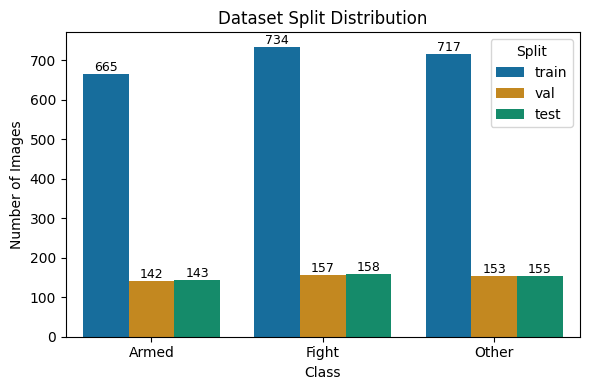

In [2]:
# get the dataset path
dataset = Path("./datasets")

splits = ["train", "val", "test"] 
classes = ["Armed", "Fight", "Other"]

# generate dataframe
dataset_count = [] # count of all classes in each split
# count files of classes in each split
for split in splits:
    for cls in classes:
        folder = dataset / split / cls
        count = len(list(folder.iterdir())) 
        dataset_count.append([split, cls, count])

# convert to DataFrame
dataset_count = pd.DataFrame(dataset_count, columns=["Split", "Class", "Count"])
# Plot the bar
plt.figure(figsize=(6,4), facecolor="white", dpi=100)
ax = sns.barplot(dataset_count, x="Class", y="Count", hue="Split", palette="colorblind")
# display the image count above each bar.
# The implementation approach for adding bar labels was assisted by AI.
for container in ax.containers:
    ax.bar_label(container, fmt="%d", fontsize=9)
# Set labels and titles
plt.title("Dataset Split Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
# Show and Save
plt.tight_layout()
plt.savefig(
    "./resources/dataset-split-distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close() # cleans the memory while showing in the cell

### Sample Images
Demonstarates sample image present in the final dataset

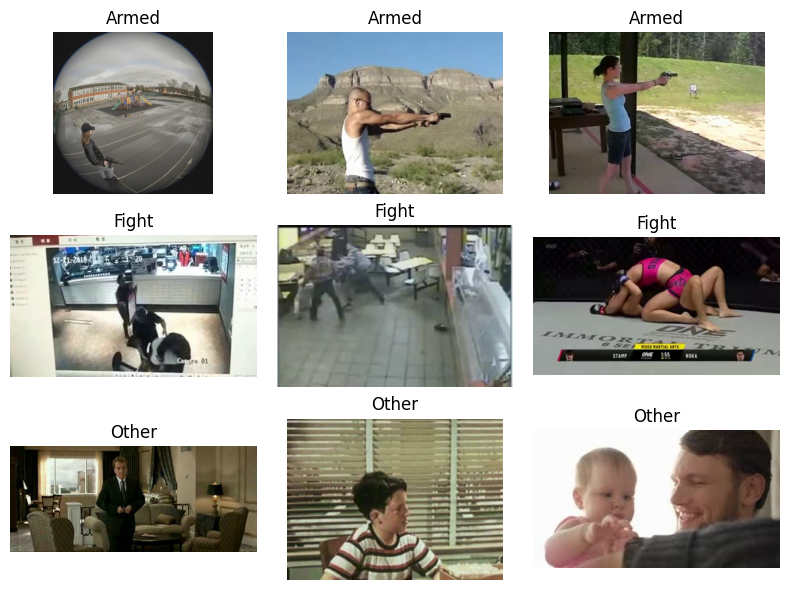

In [3]:
# A canvas 
plt.figure(figsize=(8, 6))
samples = 3 # constant samples to show
i = 1 # index for tracking
random.seed(40)
# loop each class and randomly select
for cls in classes:
    folder = dataset / "train" / cls
    # list all image in train set for the class
    images = list(folder.iterdir())
    selected = random.sample(images, samples) # select a random image

    # show selected sample images in a row
    for img_path in selected:
        img = Image.open(img_path)
        # create a subplot 
        plt.subplot(len(classes), samples, i) 
        plt.imshow(img) # show image
        plt.axis("off") # dont show x,y axis
        plt.title(cls) # title same as class

        i += 1

plt.tight_layout()
plt.savefig(
    "./resources/dataset-samples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# Architecture Design on Controlled Environment

A controlled environment has been setup for this study. This environment will set a border-line to make changes on the architecture making the study stay on track. The Limits or constants set as for controlled environment are:
* batch size must be 32
* epochs is set to be 100
* 64x64x3 image size will be used throughout the study
* CrossEntropy is the loss function
* Kernel Size of Convolutional Block must always be 3x3
* Padding & stride on kernel size is always 1
* Pooling layer only uses MaxPool with 2x2 kernel size and 2 stride
* Batch Normalization `BatchNorm2d()` is always applied immediately after Convolutaional block `Conv2d()`
* The initial convolutional layer's output features must be 8
* Each convolutional layer doubles the output features
* SGD optimization is used throughout the study

The aim of this study is to identify an optimal lightweight architecture that achieves a balance between threat detection performance and computational efficiency.

A simple custom dynamic architecture has been designed for this study. The `Architecture` class inherits from `torch.nn.Module`. It has a constructor followed by two public methods `add(*modules)` and `forward(x)`. The constructor initializes a ModuleList `nn.ModuleList` which will hold the model blocks. The add method creates a sequential block `nn.Sequential` holding all the module blocks recieved from parameters, then appends the sequential block to the ModuleList. The forward method is developed to handle forward pass in the ModuleList.


In [4]:
# import torch and torch.nn 
import torch
import torch.nn as nn


class Architecture(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.blocks = nn.ModuleList()
        
    def add(self, *modules):
        new_sequential = nn.Sequential(*modules)
        self.blocks.append(new_sequential)
    
    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return x
    
criterion = nn.CrossEntropyLoss()

## Dynamic function for appending convolutional Layers

Different experiment may contain varying depth of convolutional layer and pooling layer. This results into multiple similar code written for each experiment so a dynamic function `add_conv_layers(layers=1, skip_pool=0)` is developed. The function loops for number of layers defined to add convolutional layer on the model `Architecture`. It uses skip_pool to skip pooling as per required.

The `add_conv_layer` function always creates convolutional layer with 3x3 kernel size, 1 padding and 1 stride. Each convolutional block is followed by batch normalization and a ReLU. It has a fixed pooling utilizing only MaxPooling with kernel size 2x2 and stride 2. It has fixed out_channels to be 8 for the first convolutional layer. The function doubles the out_channels for each next convolutional layer. Therefore, it clearly follows the controlled environment guidelines.

In [5]:
def add_conv_layers(model, layers=1, skip_pool=0):
    # define in and out channels
    in_channels = 3
    out_channels = 8
    # size
    size = 64
    # skip pool increase by one for calculation
    skip_pool = skip_pool+1
    # save a trainable parameters
    total_conv_params = 0
    # loop each layers to add on model
    for layer in range(layers):
        # Convolutional Layer
        model.add(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )
        # calculate trainable params
        total_conv_params += (((3*3*in_channels) + 1) * out_channels) + (2*out_channels)
        # Pooling Layer
        if  (layer + 1) % skip_pool==0:
            model.add(nn.MaxPool2d(2,2))
            size = size//2
        # update in and out channels
        if (layer<layers-1):
            in_channels = out_channels
            out_channels = out_channels*2
    # return total convolutional layer parameters
    return total_conv_params, out_channels, size

# Loading dataset for training and validation
The training and validation sets are loaded using `datasets`, `transforms` from `torchvision` and `DataLoader` from torch.utils.data. Both the training sets and validation sets will use dataset without augmentations. Following the controlled environment, 32 will be the batch size and transforms will resize images to 64x64.

In [6]:
# import required libraries
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# create a transforms function
transform = transforms.Compose([
    transforms.Resize((64, 64)), # resizes image to 64x64
    transforms.ToTensor() # converts to pytorch tensor
])

# training dataset
train_dataset = datasets.ImageFolder(
    "./datasets/train",
    transform=transform
) # loads labeled data from folder and applies transformation
train = DataLoader(
    train_dataset, 
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    shuffle=True,
    persistent_workers=True
)

# validation dataset
val_dataset = datasets.ImageFolder(
    "./datasets/val",
    transform=transform
) # loads labeled data from folder and applies transformation
val = DataLoader(
    val_dataset, 
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

# Custom Modules for Training, testing and plotting

For this study, custom modules were developed for Training, testing and plotting charts. These modules have long and complex codes, making them not suitable to place on a single jupyter file with experiments. They are placed inside `/module` directory allowing this notebook to directly access as `from modules.x import x` and use it.

The `Trainer` module is a class that has major role in training the models for this study. It takes model, train_dataloader,val_dataloader, otimizer, device and criterion as the parameters during initialization. It consists of a constructor, a private method `__train_one_epoch` and a public method `fit`. The constructor stores all the values passed as arguments during initialization and set model to load on `device`. The private method `__train_one_epoch` recieves `data` a training data from data loader as a parameters. This method simply loops the `data` to extract x and y then load them on the mentioned `device`. It then performs forward pass on `self.model`, loss calculation using `self.criterion`, backward propagation follwed with optimizer steps `self.optimizer`. The trainer function uses `torch.argmax()` to make predictions from logits then finally, returns loss, predictions and target values from training. The public method `fit` accepts `epochs`, `save_path` and `checkpoints` as parameters. It iterates for mentioned epoch and use private method `__train_one_epoch` for training model then passes to another custom function `calculate_metrics` to calculate its accuracy, precision, recall and f1-score. This function uses a custom `evaluator` module for evaluating model's performance on validation set then passes it to `calculate_metrics` to calculate its metrics. It saves the checkpoints on `save_path`. Finally the `fit` method converts all training and validation metrics collected to a pandas DataFrame saving on the disk then returns the DataFrame.

The `tester` module is a simple function that accepts model, save_path, data, criterion, device as parameters and use custom `evaluator` module to evaluate a certain model. This function uses `calculate_metrics` after `evaluator` then returns the metrics of tested model.

`get_line_charts` is a simple module that use internal custom functions to draw line charts comparing training and validation set for individual metrics including loss, accuracy, precision, recall and f1-score utilizing famous python libraries such as matplotlib and seaborn.

`evaluator` is a custom function that passes data inside the model in evaluation mode, calculates the loss, then return loss, predictions and target values. Unlike Trainer it does not use backward propagation and optimization.

`calculate_metrics` is a very basic function that accepts actual, predicted and prefix as parameters. It utilizes sklearn.metrics function for calculating accuracy, precision, recall and f1-score. It converts actual and predicted tensors into a numpy array then uses sklearn's function to calculate. Finally it returns an object containing all metrics where each key has a custom prefix sent from parameters.

Each modules are present inside `\modules` in the GitHub repository - https://github.com/tikadatta2005/efficient-surveillance-system-research . This repository has individualized experiments on seperate files and all the resources inside `\resources` and the experimental output inside `]\experiments`

In [7]:
from modules.trainer import Trainer
from modules.tester import test
from modules.charts import gen_line_charts

### Find best model having highest accuracy on validation set
A custom function was developed to find the best-performing models based on validation accuracy and validation F1-score. The logic of the function is simple: it uses the pandas `.max()` function to find the highest validation accuracy and prints the corresponding row. Similarly, it finds the highest validation F1-score and prints the corresponding row.

In [8]:
def find_best_models(df):
    best_acc = df[df["val_accuracy"] == df["val_accuracy"].max()] # find best accuracy
    best_f1 = df[df["val_f1_score"] == df["val_f1_score"].max()] # find best f1-score
    best = pd.concat([best_acc, best_f1]).drop_duplicates() # combines and remove duplicates
    return best

# Experiment 1
## e1_4_layered_no_aug

This is the baseline experiment where an architecture with 4 convolutional layers, each followed by a pooling layer, is used. This experiment uses a learning rate of 2e-3. It does not use any augmentations during training.

Input vector size = 1024
Total trainable parameters = 131587
EPOCH 5 completed | Training Loss = 0.8194929379135815 | Validation Loss = 0.867699138323466
EPOCH 10 completed | Training Loss = 0.6350881363918532 | Validation Loss = 0.7672646542390188
EPOCH 15 completed | Training Loss = 0.5201051737835158 | Validation Loss = 0.7242333134015401
EPOCH 20 completed | Training Loss = 0.4342270311134965 | Validation Loss = 0.7927694976329803
EPOCH 25 completed | Training Loss = 0.3733155807452415 | Validation Loss = 1.4767469823360444
EPOCH 30 completed | Training Loss = 0.30904664455065084 | Validation Loss = 0.9199459423621495
EPOCH 35 completed | Training Loss = 0.2682768829278092 | Validation Loss = 0.6901809858779112
EPOCH 40 completed | Training Loss = 0.21326359683897958 | Validation Loss = 0.9337861527999242
EPOCH 45 completed | Training Loss = 0.16806310370786867 | Validation Loss = 0.8266529079526663
EPOCH 50 completed | Training Loss = 0.1437792991524312 | Validation Loss = 0.61177

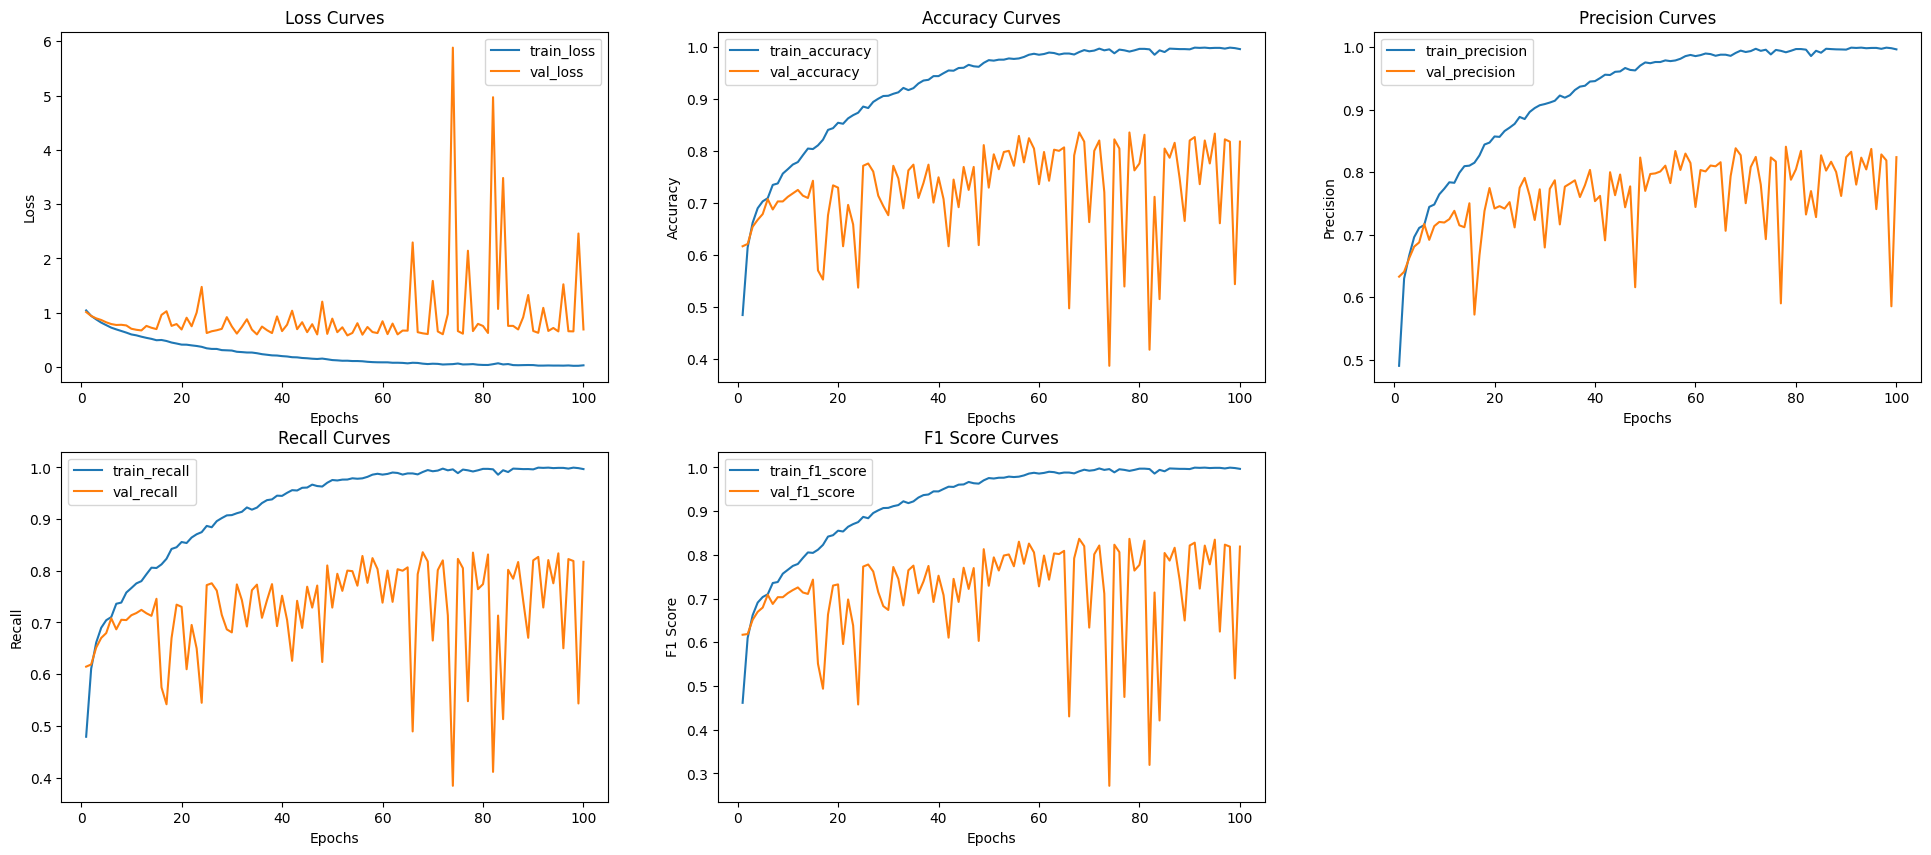

Best Model


,epoch,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1_score,val_accuracy,val_precision,val_recall,val_f1_score
67,68,0.063647,0.622145,0.991021,0.991042,0.991075,0.991053,0.836283,0.838426,0.835893,0.836788
77,78,0.055336,0.663215,0.991966,0.992093,0.992110,0.992100,0.836283,0.840888,0.835165,0.836686


In [9]:
torch.manual_seed(40)
# initialize new Architecture
model_e1 = Architecture()


# add layers
e1_conv_params, e1_out_channels, e1_size = add_conv_layers(model_e1, 4, 0)

# calculate next input channels
n_in = e1_out_channels*e1_size*e1_size
print(f"Input vector size = {n_in}")

# add fully connected neural networks
model_e1.add(
    # Flatten
    nn.Flatten(),
    # Hidden Layer
    nn.Linear(n_in, 128),
    nn.ReLU(),
    # Output Layer
    nn.Linear(128, 3),
)

# calculate parameters
e1_total_trainable_parameters = ((n_in*128)+128) + ((128*3)+3)
print(f"Total trainable parameters = {e1_total_trainable_parameters}")

# path to save models
path = "./exp/e1_4_layers_no_aug"

# optimizer
optimizer = torch.optim.SGD(model_e1.parameters(), lr=2e-3)

# train model
trainer = Trainer(
    model_e1,
    train,
    val,
    optimizer,
    "cuda",
    criterion
)
e1_metrics = trainer.fit(100, path, 1);

# show chart comparing metrics
gen_line_charts(e1_metrics, path, "training_metrics_graph.png", ["train_", "val_"])

# Show best models
print("Best Model")
display(find_best_models(e1_metrics))

# clean up
del model_e1, optimizer, trainer
torch.cuda.empty_cache()

### Evaluataion of model peroformance based on the validation and training metrics throuhout 100 for the first experiment

# Load dataset for training with augmentation for further Experiments

In [10]:
# create a transforms function
transform_aug = transforms.Compose([
    transforms.Resize((64, 64)), # resizes image to 64x64
    transforms.RandomHorizontalFlip(p=0.5), # Flips horizontally for 50% images
    transforms.RandomRotation(10), # rorates between +- 10deg
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.5
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.12, 0.12),
        scale=(0.8, 1.2)
    ), # moves data sliglhty with some scaling
    transforms.ToTensor(), # convert to python tensors
])
# training dataset
train_dataset_aug = datasets.ImageFolder(
    "./datasets/train",transform_aug
) 
# loads labeled data from folder and applies transformation
train_aug = DataLoader(
    train_dataset_aug, 
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    shuffle=True,
    persistent_workers=True
)

# Experiment 2
## e2_4_layered_with_aug

This is the extention of baseline experiment that uses some augmentation on the dataset. It uses 4 convolutional layers each followed with a pooling layer and 2e-3 learning rate.

Input vector size = 1024
Total trainable parameters = 131587
EPOCH 5 completed | Training Loss = 0.9757826025806257 | Validation Loss = 0.9808204213778178
EPOCH 10 completed | Training Loss = 0.899937754246726 | Validation Loss = 0.905531398455302
EPOCH 15 completed | Training Loss = 0.8422031642785713 | Validation Loss = 0.8289423902829488
EPOCH 20 completed | Training Loss = 0.8117901309212642 | Validation Loss = 0.8348839938640594
EPOCH 25 completed | Training Loss = 0.7792246395082616 | Validation Loss = 0.8414290249347687
EPOCH 30 completed | Training Loss = 0.7294718334034308 | Validation Loss = 1.3813800096511841
EPOCH 35 completed | Training Loss = 0.7240647976078204 | Validation Loss = 1.49735416273276
EPOCH 40 completed | Training Loss = 0.6915641578275766 | Validation Loss = 0.6797426680723826
EPOCH 45 completed | Training Loss = 0.7146793844094917 | Validation Loss = 0.7904732048511505
EPOCH 50 completed | Training Loss = 0.6693964035653356 | Validation Loss = 0.87798283124

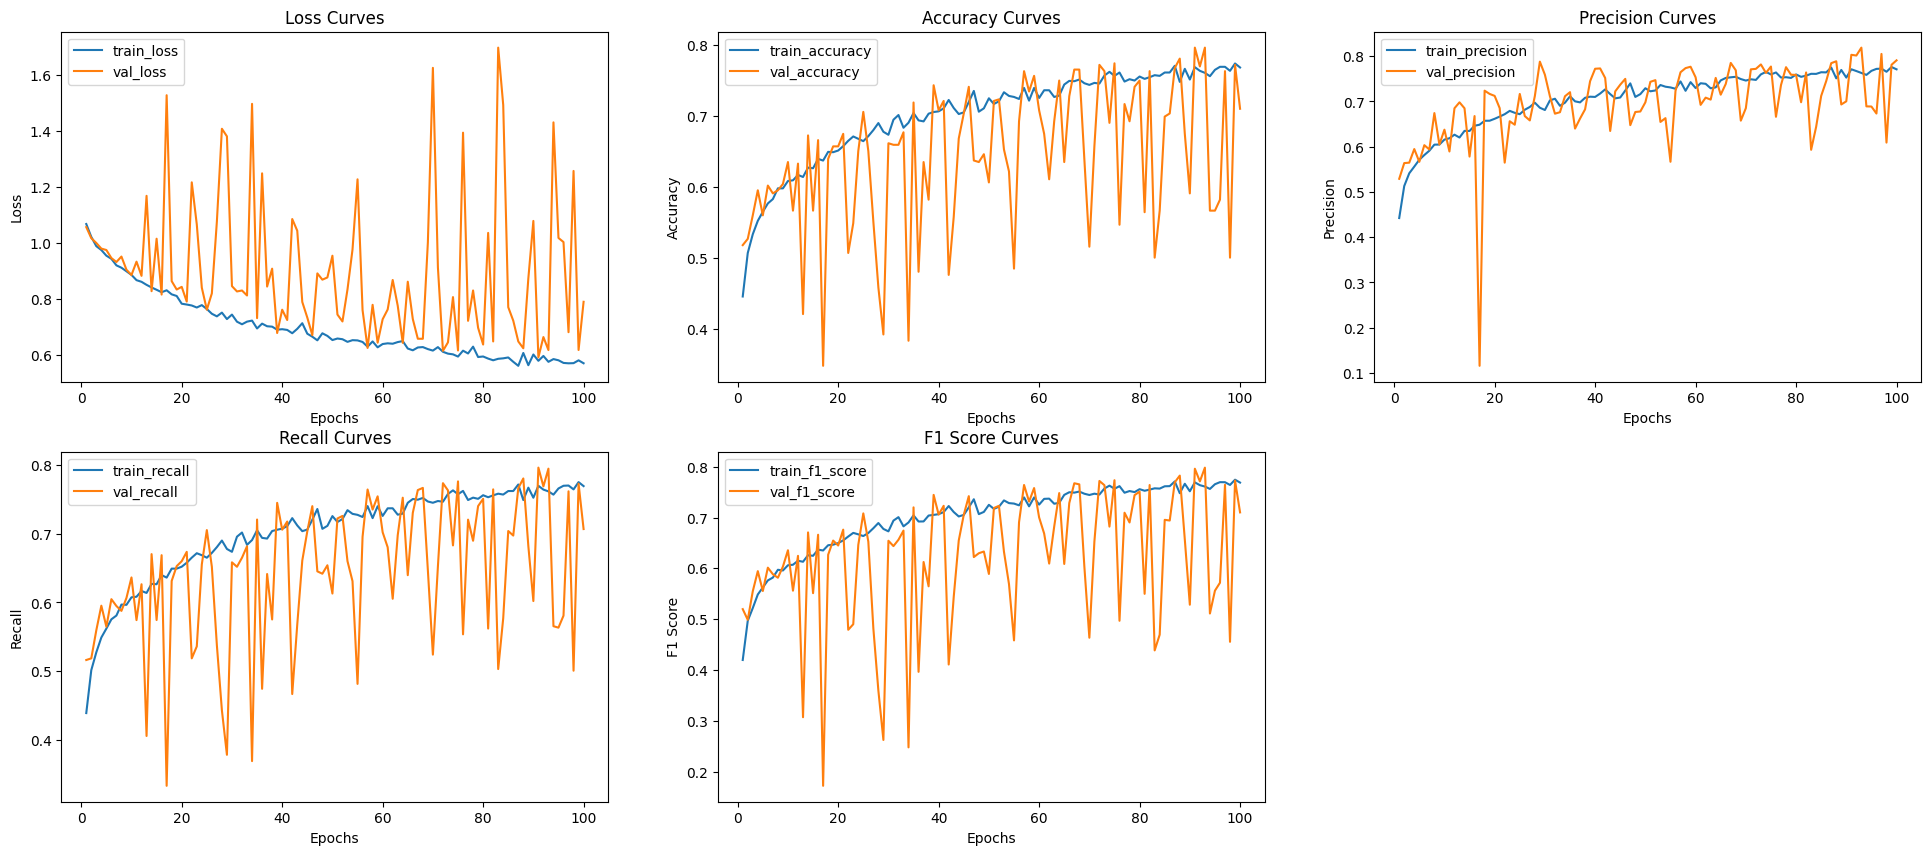

Best Model


,epoch,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1_score,val_accuracy,val_precision,val_recall,val_f1_score
90,91,0.580562,0.592668,0.768904,0.770949,0.769618,0.769373,0.79646,0.802917,0.796046,0.796255
92,93,0.576904,0.618875,0.760870,0.762824,0.761522,0.761153,0.79646,0.818774,0.794545,0.798381


In [11]:
torch.manual_seed(40)

# initialize new Architecture
model_e2 = Architecture()

# add layers
e2_conv_params, e2_out_channels, e2_size = add_conv_layers(model_e2, 4, 0)

# calculate next input channels
n_in = e2_out_channels*e2_size*e2_size
print(f"Input vector size = {n_in}")

# add fully connected neural networks
model_e2.add(
    # Flatten
    nn.Flatten(),
    # Hidden Layer
    nn.Linear(n_in, 128),
    nn.ReLU(),
    # Output Layer
    nn.Linear(128, 3),
)

# calculate parameters
e2_total_trainable_parameters = ((n_in*128)+128) + ((128*3)+3)
print(f"Total trainable parameters = {e2_total_trainable_parameters}")

# path to save models
path = "./exp/e2_4_layers_aug"

# optimizer
optimizer = torch.optim.SGD(model_e2.parameters(), lr=2e-3)
# train model
trainer = Trainer(
    model_e2,
    train_aug,
    val,
    optimizer,
    "cuda",
    criterion
)
e2_metrics = trainer.fit(100, path, 1);

# show chart comparing metrics
gen_line_charts(e2_metrics, path, "training_metrics_graph.png", ["train_", "val_"])

# find the best model
print("Best Model")
display(find_best_models(e2_metrics))

# clean up
del model_e2, optimizer, trainer
torch.cuda.empty_cache()

### Evaluataion of model peroformance based on the validation and training metrics throuhout 100 for the second experiment

# Experiment 3
## e3_8_layered_with_aug

This is the extention of e2 experiment that uses some augmentation on the dataset. It uses 8 convolutional layers where a pooling layer skips 1 convolutional layer. The learning rate is 2e-3.

Input vector size = 16384
Total trainable parameters = 2097667
EPOCH 5 completed | Training Loss = 0.8329536923721655 | Validation Loss = 0.8355718235174815
EPOCH 10 completed | Training Loss = 0.734018276876478 | Validation Loss = 0.8099032521247864
EPOCH 15 completed | Training Loss = 0.6622419290578188 | Validation Loss = 0.680987028280894
EPOCH 20 completed | Training Loss = 0.6403388945914027 | Validation Loss = 1.1861976573864619
EPOCH 25 completed | Training Loss = 0.6320397738200515 | Validation Loss = 0.854773411154747
EPOCH 30 completed | Training Loss = 0.5840775868785915 | Validation Loss = 1.2241202183067799
EPOCH 35 completed | Training Loss = 0.563810960570378 | Validation Loss = 0.8154975021878879
EPOCH 40 completed | Training Loss = 0.534371815955461 | Validation Loss = 1.2559873392184575
EPOCH 45 completed | Training Loss = 0.5076904425870127 | Validation Loss = 0.8419722579419613
EPOCH 50 completed | Training Loss = 0.48059092261897984 | Validation Loss = 0.574797325

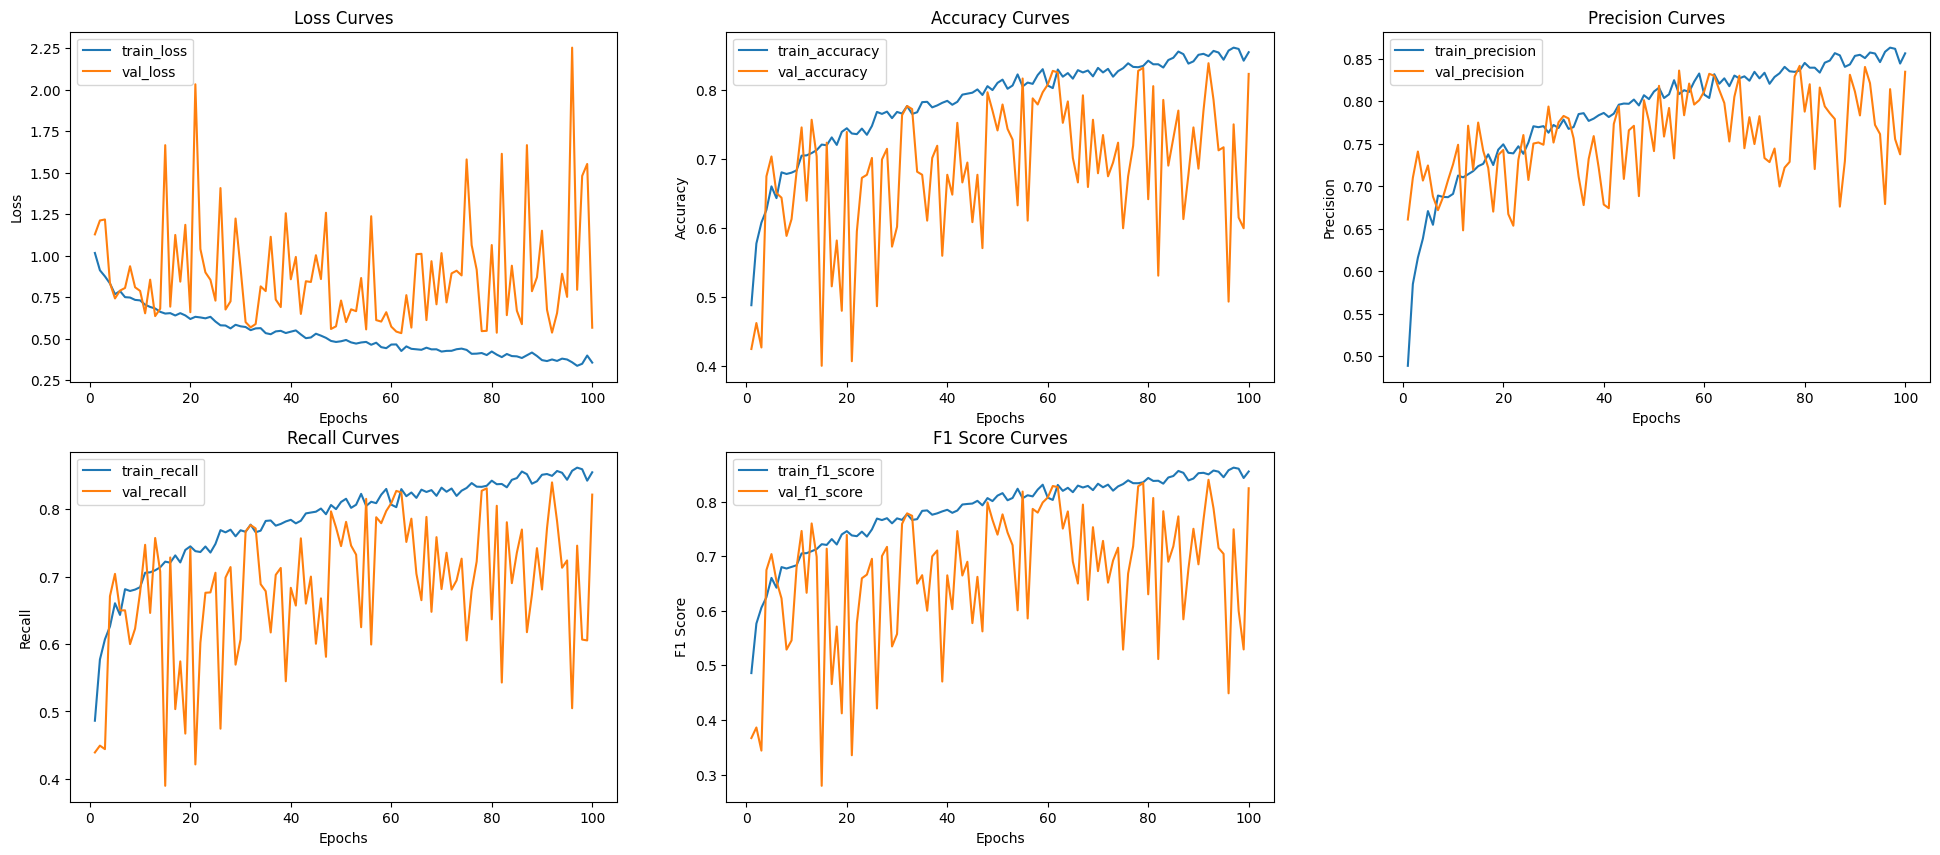

Best Model


,epoch,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1_score,val_accuracy,val_precision,val_recall,val_f1_score
91,92,0.375208,0.536759,0.848771,0.850648,0.849734,0.849917,0.838496,0.840246,0.840035,0.840021


In [12]:
torch.manual_seed(40)

# initialize new Architecture
model_e3 = Architecture()

# add layers
e3_conv_params, e3_out_channels, e3_size = add_conv_layers(model_e3, 8, 1)

# calculate next input channels
n_in = e3_out_channels*e3_size*e3_size
print(f"Input vector size = {n_in}")

# add fully connected neural networks
model_e3.add(
    # Flatten
    nn.Flatten(),
    # Hidden Layer
    nn.Linear(n_in, 128),
    nn.ReLU(),
    # Output Layer
    nn.Linear(128, 3),
)

# calculate parameters
e3_total_trainable_parameters = ((n_in*128)+128) + ((128*3)+3)
print(f"Total trainable parameters = {e3_total_trainable_parameters}")

# path to save models
path = "./exp/e3_8_layers_aug"

# optimizer
optimizer = torch.optim.SGD(model_e3.parameters(), lr=2e-3)

# train model
trainer = Trainer(
    model_e3,
    train_aug,
    val,
    optimizer,
    "cuda",
    criterion
)
e3_metrics = trainer.fit(100, path, 1);

# show chart comparing metrics
gen_line_charts(e3_metrics, path, "training_metrics_graph.png", ["train_", "val_"])

# find best models
print("Best Model")
display(find_best_models(e3_metrics))
# clean up
del model_e3, optimizer, trainer
torch.cuda.empty_cache()

### Evaluataion of model peroformance based on the validation and training metrics throuhout 100 for the third experiment

# Experiment 4
## e4_8_layered_no_aug

The fourth experiment uses 8 convolutional layers. 4 pooling layer is utilzed where each pooling is applied skipping 1 pooling layer.

Input vector size = 16384
Total trainable parameters = 2097667
EPOCH 5 completed | Training Loss = 0.500507309143223 | Validation Loss = 0.7444052139918009
EPOCH 10 completed | Training Loss = 0.2205758674153641 | Validation Loss = 1.6702947386230032
EPOCH 15 completed | Training Loss = 0.09700777125892354 | Validation Loss = 1.0228626216451326
EPOCH 20 completed | Training Loss = 0.041753096895209 | Validation Loss = 6.513386415162434
EPOCH 25 completed | Training Loss = 0.02361272813390885 | Validation Loss = 1.3737649186824759
EPOCH 30 completed | Training Loss = 0.013018506426197379 | Validation Loss = 1.1068437597403924
EPOCH 35 completed | Training Loss = 0.01623917090942833 | Validation Loss = 0.5818638190627098
EPOCH 40 completed | Training Loss = 0.06656416870459024 | Validation Loss = 0.9736131553848585
EPOCH 45 completed | Training Loss = 0.00909272007254967 | Validation Loss = 0.5529264415303866
EPOCH 50 completed | Training Loss = 0.005507268819527061 | Validation Loss = 0

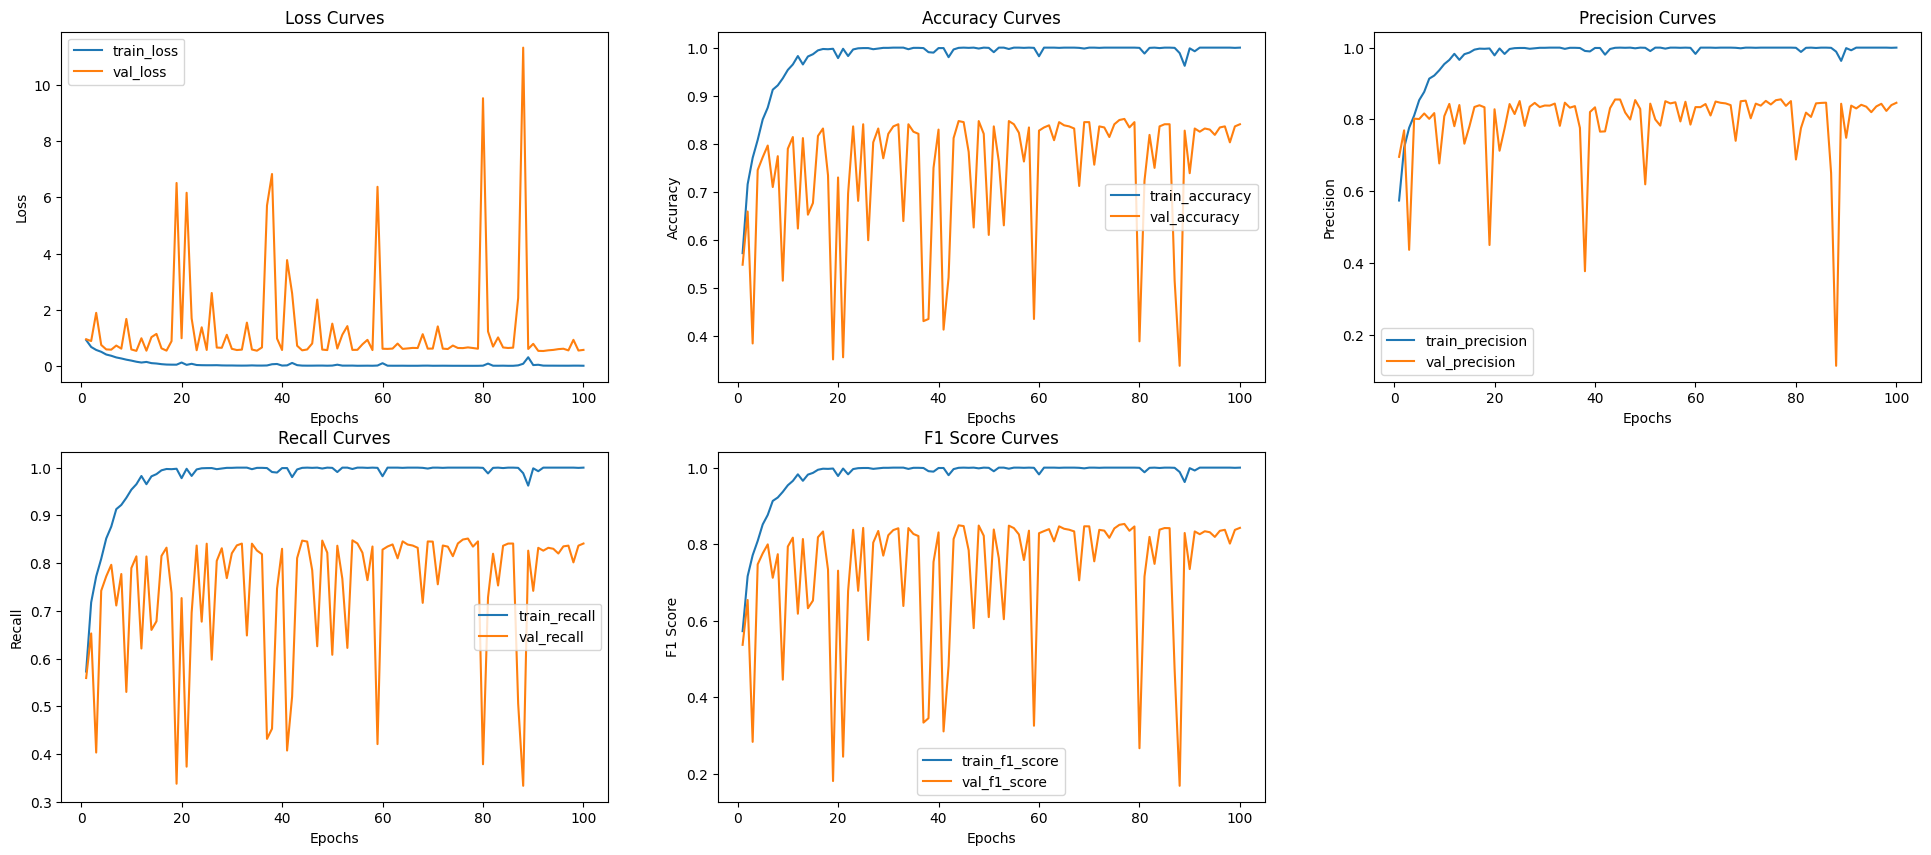

Best Model


,epoch,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1_score,val_accuracy,val_precision,val_recall,val_f1_score
76,77,0.002057,0.657511,1.0,1.0,1.0,1.0,0.85177,0.855848,0.851425,0.852859


In [13]:
torch.manual_seed(40)

# initialize new Architecture
model_e4 = Architecture()

# add layers
e4_conv_params, e4_out_channels, e4_size = add_conv_layers(model_e4, 8, 1)

# calculate next input channels
n_in = e4_out_channels*e4_size*e4_size
print(f"Input vector size = {n_in}")

# add fully connected neural networks
model_e4.add(
    # Flatten
    nn.Flatten(),
    # Hidden Layer
    nn.Linear(n_in, 128),
    nn.ReLU(),
    # Output Layer
    nn.Linear(128, 3),
)

# calculate parameters
e4_total_trainable_parameters = ((n_in*128)+128) + ((128*3)+3)
print(f"Total trainable parameters = {e4_total_trainable_parameters}")

# path to save models
path = "./exp/e4_8_layers_no_aug"

# optimizer
optimizer = torch.optim.SGD(model_e4.parameters(), lr=2e-3)

# train model
trainer = Trainer(
    model_e4,
    train,
    val,
    optimizer,
    "cuda",
    criterion
)
e4_metrics = trainer.fit(100, path, 1);

# show chart comparing metrics
gen_line_charts(e4_metrics, path, "training_metrics_graph.png", ["train_", "val_"])


# Show best models
print("Best Model")
display(find_best_models(e4_metrics))

# clean up
del model_e4, optimizer, trainer
torch.cuda.empty_cache()

### Evaluataion of model peroformance based on the validation and training metrics throuhout 100 for the fourth experiment

# Experiment 5
## e5_e4_lower_lr

The fifth experiment is extended version of the fourth experiment. It uses 8 convolutional layer followed by pooling layer each being skipped exactly ones resulting to 4 pooling layers. The learning rate is changed from 2e-3 to 3e-4.

Input vector size = 16384
Total trainable parameters = 2097667
EPOCH 5 completed | Training Loss = 0.7826582905071885 | Validation Loss = 0.8586807946364085
EPOCH 10 completed | Training Loss = 0.6001539154728847 | Validation Loss = 0.719632883866628
EPOCH 15 completed | Training Loss = 0.4924784912102258 | Validation Loss = 0.659167472521464
EPOCH 20 completed | Training Loss = 0.4128758698257048 | Validation Loss = 0.6799179991086324
EPOCH 25 completed | Training Loss = 0.34594701630855673 | Validation Loss = 0.6355640769004822
EPOCH 30 completed | Training Loss = 0.29158420593880896 | Validation Loss = 0.6636752635240555
EPOCH 35 completed | Training Loss = 0.23534200040262138 | Validation Loss = 0.5575573951005935
EPOCH 40 completed | Training Loss = 0.20636982782118357 | Validation Loss = 0.600941276550293
EPOCH 45 completed | Training Loss = 0.1728606704455703 | Validation Loss = 0.5415378938118617
EPOCH 50 completed | Training Loss = 0.14188453332701725 | Validation Loss = 0.533

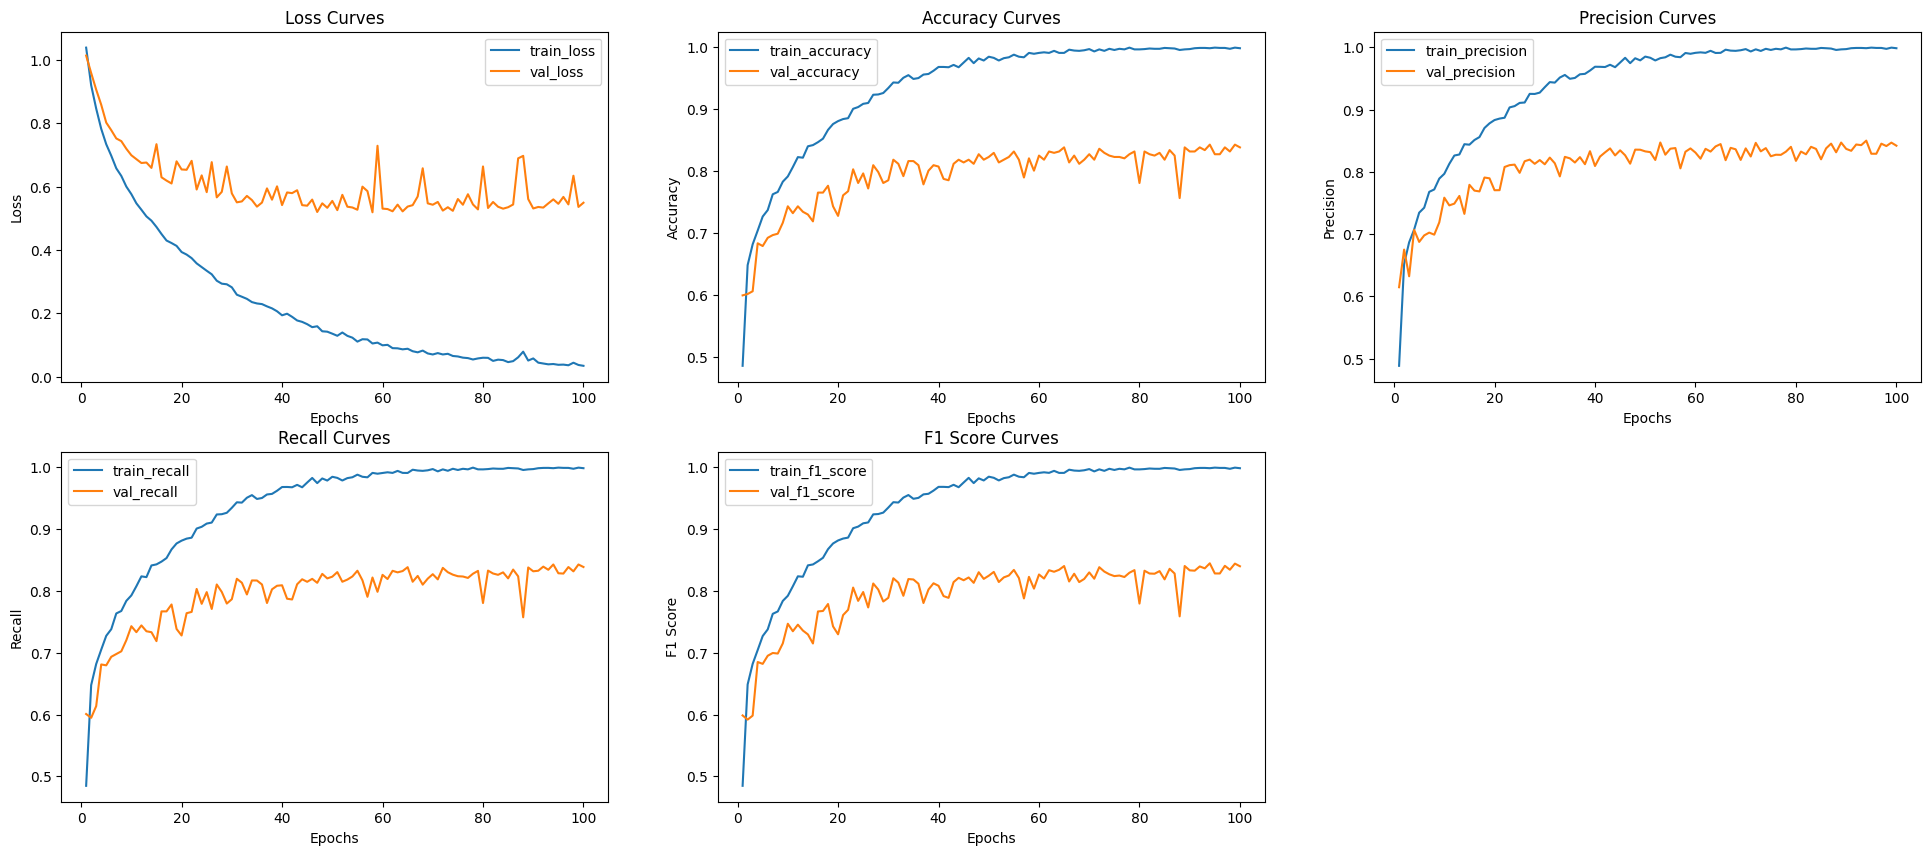

Best Model


,epoch,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1_score,val_accuracy,val_precision,val_recall,val_f1_score
93,94,0.039767,0.559744,0.998582,0.998643,0.998605,0.998621,0.84292,0.850141,0.842820,0.844689
98,99,0.036759,0.535903,0.999527,0.999536,0.999499,0.999517,0.84292,0.846935,0.842766,0.844209


In [14]:
torch.manual_seed(40)

# initialize new Architecture
model_e5 = Architecture()

# add layers
e5_conv_params, e5_out_channels, e5_size = add_conv_layers(model_e5, 8, 1)

# calculate next input channels
n_in = e5_out_channels*e5_size*e5_size
print(f"Input vector size = {n_in}")

# add fully connected neural networks
model_e5.add(
    # Flatten
    nn.Flatten(),
    # Hidden Layer
    nn.Linear(n_in, 128),
    nn.ReLU(),
    # Output Layer
    nn.Linear(128, 3),
)

# calculate parameters
e5_total_trainable_parameters = ((n_in*128)+128) + ((128*3)+3)
print(f"Total trainable parameters = {e5_total_trainable_parameters}")

# path to save models
path = "./exp/e5_ext_e4_lower_lr"

# optimizer
optimizer = torch.optim.SGD(model_e5.parameters(), lr=3e-4)

# train model
trainer = Trainer(
    model_e5,
    train,
    val,
    optimizer,
    "cuda",
    criterion
)
e5_metrics = trainer.fit(100, path, 1);

# show chart comparing metrics
gen_line_charts(e5_metrics, path, "training_metrics_graph.png", ["train_", "val_"])


# Show best models
print("Best Model")
display(find_best_models(e5_metrics))

# clean up
del model_e5, optimizer, trainer
torch.cuda.empty_cache()

### Evaluataion of model peroformance based on the validation and training metrics throuhout 100 for the fifth experiment

# Experiment 6
## e6_e1_lower_lr

The fifth experiment showed smooth learning with very less to no fluctuations in validation set on lower learning rate. Using the lower learning rate 3e-4 on first experiment to visualize if only learning rate is effective or the combination of convolutional layers, pooling layers and learning rate makes it effective. 

Input vector size = 1024
Total trainable parameters = 131587
EPOCH 5 completed | Training Loss = 1.0272336806823958 | Validation Loss = 1.028767188390096
EPOCH 10 completed | Training Loss = 0.9555128145573745 | Validation Loss = 0.9794809897740682
EPOCH 15 completed | Training Loss = 0.8995112847926011 | Validation Loss = 0.9373659928639729
EPOCH 20 completed | Training Loss = 0.8544789490415089 | Validation Loss = 0.899809193611145
EPOCH 25 completed | Training Loss = 0.8127850400867747 | Validation Loss = 0.8669942816098531
EPOCH 30 completed | Training Loss = 0.7771624344498363 | Validation Loss = 0.8369406203428904
EPOCH 35 completed | Training Loss = 0.7377185145420815 | Validation Loss = 0.8081418414910634
EPOCH 40 completed | Training Loss = 0.7145127609594545 | Validation Loss = 0.791221926609675
EPOCH 45 completed | Training Loss = 0.683818875853695 | Validation Loss = 0.7678255041440328
EPOCH 50 completed | Training Loss = 0.6568367445646827 | Validation Loss = 0.75584594607

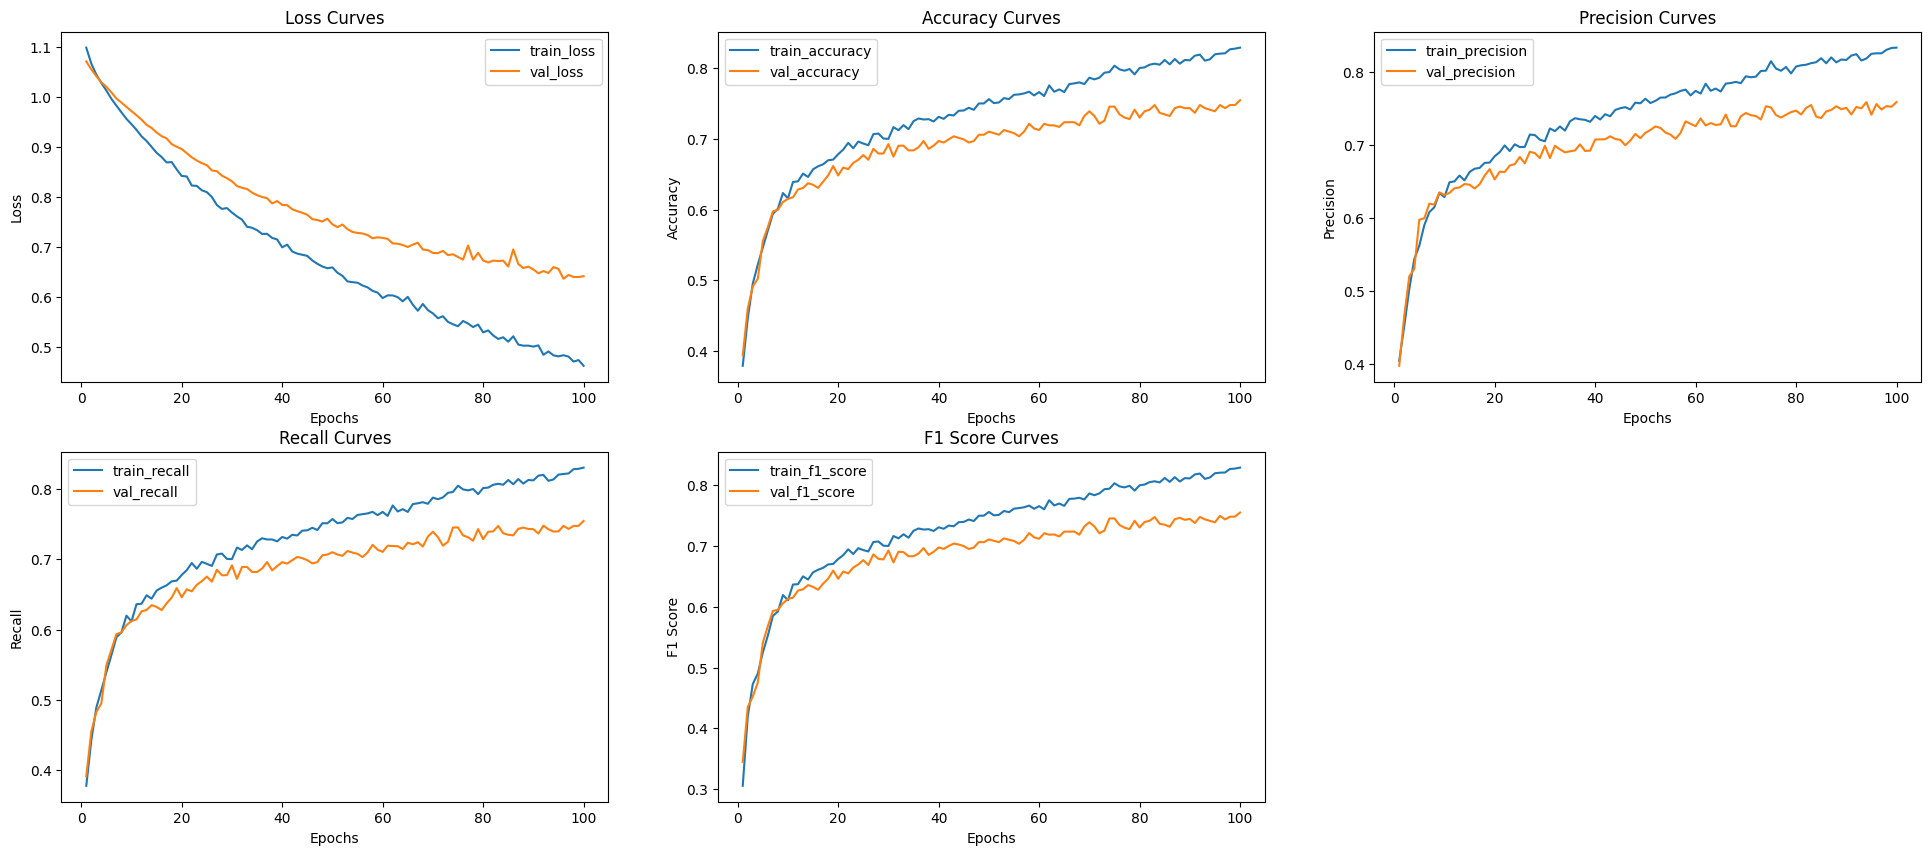

Best Model


,epoch,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1_score,val_accuracy,val_precision,val_recall,val_f1_score
99,100,0.461754,0.640941,0.828922,0.832858,0.830016,0.829003,0.754425,0.7585,0.754208,0.755117


In [15]:
torch.manual_seed(40)

# initialize new Architecture
model_e6 = Architecture()

# add layers
e6_conv_params, e6_out_channels, e6_size = add_conv_layers(model_e6, 4, 0)

# calculate next input channels
n_in = e6_out_channels*e6_size*e6_size
print(f"Input vector size = {n_in}")

# add fully connected neural networks
model_e6.add(
    # Flatten
    nn.Flatten(),
    # Hidden Layer
    nn.Linear(n_in, 128),
    nn.ReLU(),
    # Output Layer
    nn.Linear(128, 3),
)

# calculate parameters
e6_total_trainable_parameters = ((n_in*128)+128) + ((128*3)+3)
print(f"Total trainable parameters = {e6_total_trainable_parameters}")

# path to save models
path = "./exp/e6_ext_e1_lower_lr"

# optimizer
optimizer = torch.optim.SGD(model_e6.parameters(), lr=3e-4)

# train model
trainer = Trainer(
    model_e6,
    train,
    val,
    optimizer,
    "cuda",
    criterion
)
e6_metrics = trainer.fit(100, path, 1);

# show chart comparing metrics
gen_line_charts(e6_metrics, path, "training_metrics_graph.png", ["train_", "val_"])


# Show best models
print("Best Model")
display(find_best_models(e6_metrics))

# clean up
del model_e6, optimizer, trainer
torch.cuda.empty_cache()

### Evaluataion of model peroformance based on the validation and training metrics throuhout 100 for the sixth experiment

# Experiment 7
## e7_e5_aug

The third experiment showed reduction in overfitting and fifth experiment showed stable learning. This experiments tries to combine training on augmented training set and lower learning rate to examine the outcome of model.

Input vector size = 16384
Total trainable parameters = 2097667
EPOCH 5 completed | Training Loss = 0.9489074625186066 | Validation Loss = 0.9588445782661438
EPOCH 10 completed | Training Loss = 0.8795773120068792 | Validation Loss = 0.8704505562782288
EPOCH 15 completed | Training Loss = 0.831451073511323 | Validation Loss = 0.8353973627090454
EPOCH 20 completed | Training Loss = 0.8047924023955616 | Validation Loss = 0.7766938209533691
EPOCH 25 completed | Training Loss = 0.7598459226871604 | Validation Loss = 0.7520231088002522
EPOCH 30 completed | Training Loss = 0.7301607149750439 | Validation Loss = 0.7265464941660563
EPOCH 35 completed | Training Loss = 0.694058226115668 | Validation Loss = 0.6870822389920552
EPOCH 40 completed | Training Loss = 0.7023796612647042 | Validation Loss = 0.6863034864266714
EPOCH 45 completed | Training Loss = 0.6713190425687762 | Validation Loss = 0.6633135139942169
EPOCH 50 completed | Training Loss = 0.6619232434835007 | Validation Loss = 0.6497651

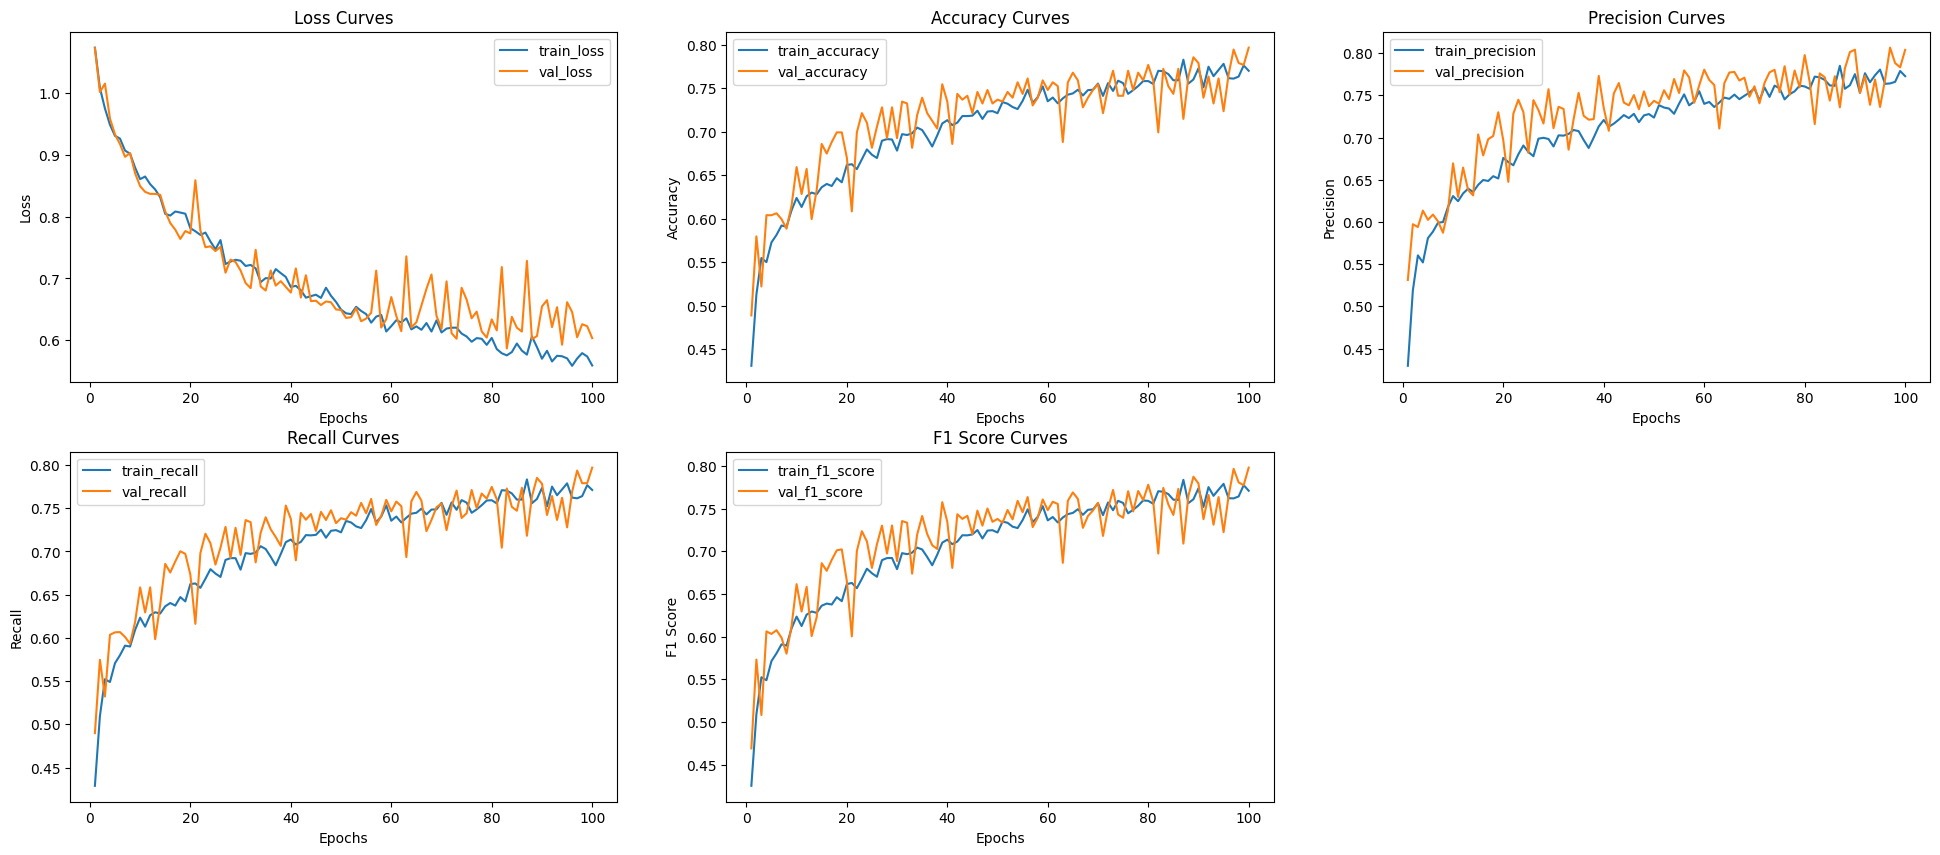

Best Model


,epoch,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1_score,val_accuracy,val_precision,val_recall,val_f1_score
99,100,0.558982,0.603288,0.769849,0.772783,0.771157,0.770832,0.79646,0.803874,0.797013,0.797899


In [16]:
torch.manual_seed(40)

# initialize new Architecture
model_e7 = Architecture()

# add layers
e7_conv_params, e7_out_channels, e7_size = add_conv_layers(model_e7, 8, 1)

# calculate next input channels
n_in = e7_out_channels*e7_size*e7_size
print(f"Input vector size = {n_in}")

# add fully connected neural networks
model_e7.add(
    # Flatten
    nn.Flatten(),
    # Hidden Layer
    nn.Linear(n_in, 128),
    nn.ReLU(),
    # Output Layer
    nn.Linear(128, 3),
)

# calculate parameters
e7_total_trainable_parameters = ((n_in*128)+128) + ((128*3)+3)
print(f"Total trainable parameters = {e7_total_trainable_parameters}")

# path to save models
path = "./exp/e7_ext_e5_aug"

# optimizer
optimizer = torch.optim.SGD(model_e7.parameters(), lr=3e-4)

# train model
trainer = Trainer(
    model_e7,
    train_aug,
    val,
    optimizer,
    "cuda",
    criterion
)
e7_metrics = trainer.fit(100, path, 1);

# show chart comparing metrics
gen_line_charts(e7_metrics, path, "training_metrics_graph.png", ["train_", "val_"])


# Show best models
print("Best Model")
display(find_best_models(e7_metrics))

# clean up
del model_e7, optimizer, trainer
torch.cuda.empty_cache()

### Evaluataion of model peroformance based on the validation and training metrics throuhout 100 for the seventh experiment

# Experiment 8
## e8_e7_momentum

The seventh experiment showed stable learning without overfitting. The model shows slight less performance suggesting underfitting so this experiment extends to experiment 7 using momentum on SGD Optimizer

Input vector size = 16384
Total trainable parameters = 2097667
EPOCH 5 completed | Training Loss = 0.8022682773533152 | Validation Loss = 0.7716383953889211
EPOCH 10 completed | Training Loss = 0.6945933290381929 | Validation Loss = 0.7087529361248016
EPOCH 15 completed | Training Loss = 0.6622907973047513 | Validation Loss = 0.6291657825311024
EPOCH 20 completed | Training Loss = 0.6338317122922015 | Validation Loss = 0.6494742810726166
EPOCH 25 completed | Training Loss = 0.5871975528660105 | Validation Loss = 0.5959029138088227
EPOCH 30 completed | Training Loss = 0.5414123530708143 | Validation Loss = 0.5788720731933912
EPOCH 35 completed | Training Loss = 0.5261335479679392 | Validation Loss = 0.6785015001893043
EPOCH 40 completed | Training Loss = 0.5137209420773521 | Validation Loss = 0.5842020362615585
EPOCH 45 completed | Training Loss = 0.4863179201510415 | Validation Loss = 0.6631791678567728
EPOCH 50 completed | Training Loss = 0.4335588537045379 | Validation Loss = 0.62109

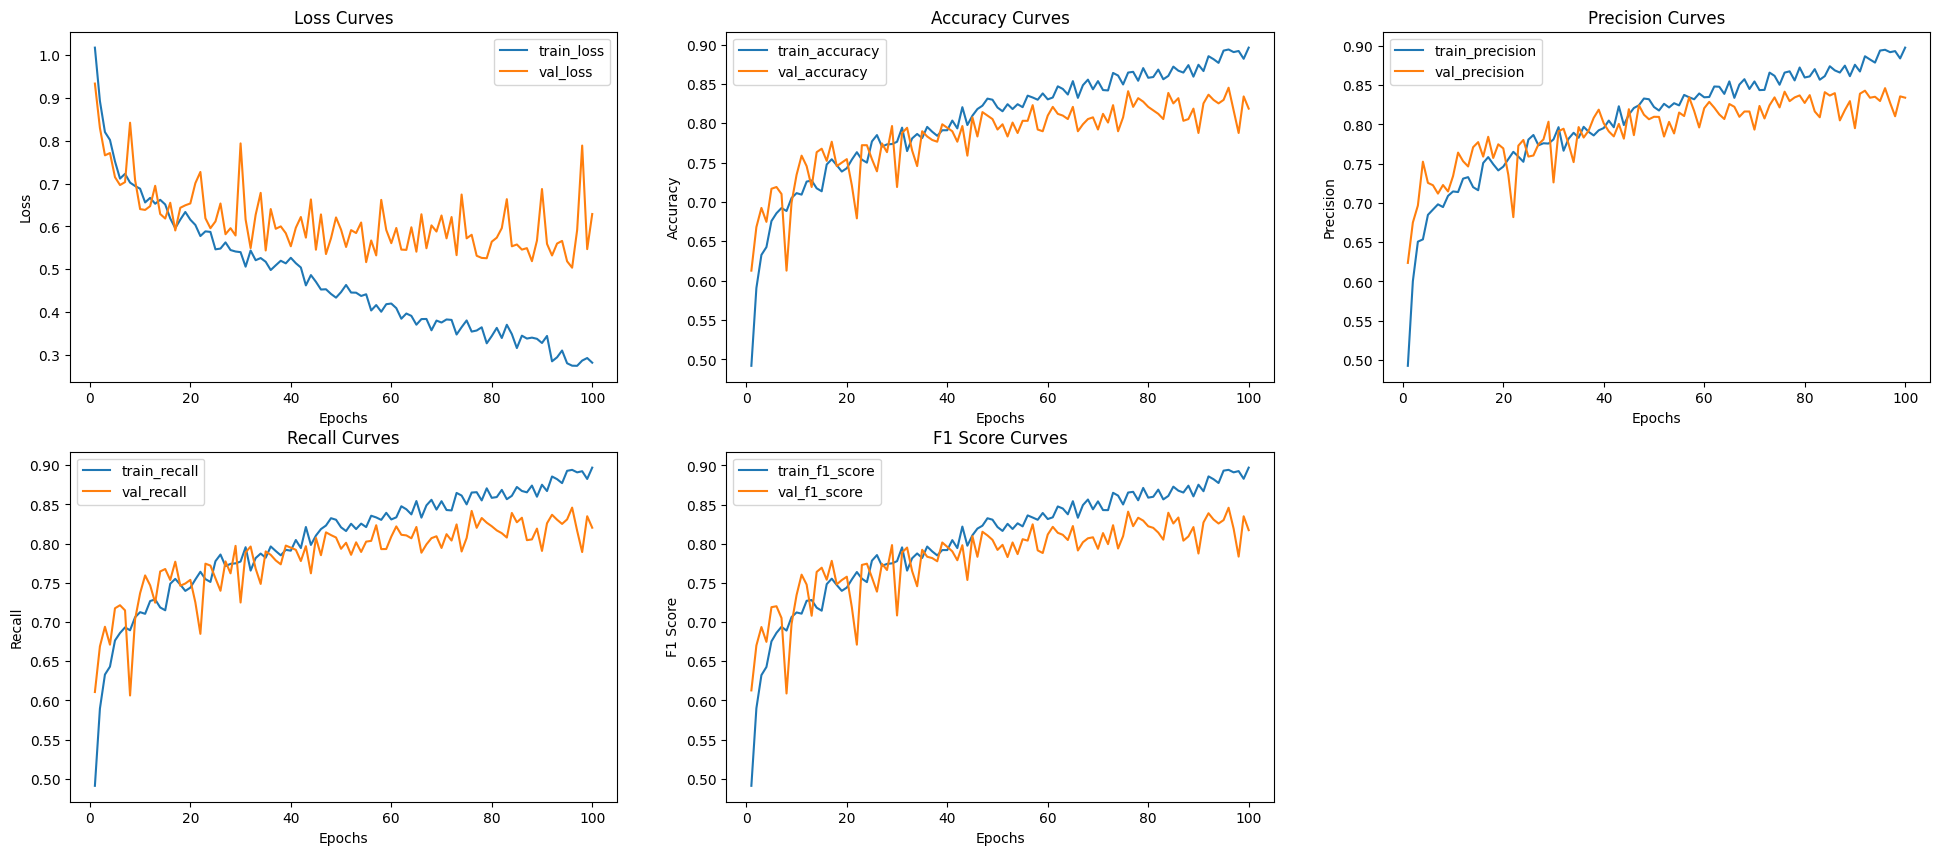

Best Model


,epoch,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1_score,val_accuracy,val_precision,val_recall,val_f1_score
95,96,0.274492,0.503562,0.893667,0.895087,0.894036,0.89437,0.845133,0.846219,0.8459,0.846007


In [19]:
torch.manual_seed(40)

# initialize new Architecture
model_e8 = Architecture()

# add layers
e8_conv_params, e8_out_channels, e8_size = add_conv_layers(model_e8, 8, 1)

# calculate next input channels
n_in = e8_out_channels*e8_size*e8_size
print(f"Input vector size = {n_in}")

# add fully connected neural networks
model_e8.add(
    # Flatten
    nn.Flatten(),
    # Hidden Layer
    nn.Linear(n_in, 128),
    nn.ReLU(),
    # Output Layer
    nn.Linear(128, 3),
)

# calculate parameters
e8_total_trainable_parameters = ((n_in*128)+128) + ((128*3)+3)
print(f"Total trainable parameters = {e8_total_trainable_parameters}")

# path to save models
path = "./exp/e8_8_ext_e7_momentum"

# optimizer
optimizer = torch.optim.SGD(model_e8.parameters(), lr=3e-4, momentum=0.9)

# train model
trainer = Trainer(
    model_e8,
    train_aug,
    val,
    optimizer,
    "cuda",
    criterion
)
e8_metrics = trainer.fit(100, path, 1);

# show chart comparing metrics
gen_line_charts(e8_metrics, path, "training_metrics_graph.png", ["train_", "val_"])

# find best models
print("Best Model")
display(find_best_models(e8_metrics))
# clean up
del model_e8, optimizer, trainer
torch.cuda.empty_cache()

# Experiment 9
## e9_aug_low_lr_momentum

The eigth experiment showed increase in validation metrics with momentum added. The previous experiment seemed to extract feature and converge slower, the architecture uses 10conv blocks

In [ ]:
torch.manual_seed(40)

# initialize new Architecture
model_e9 = Architecture()

# add layers
e9_conv_params, e9_out_channels, e9_size = add_conv_layers(model_e9, 10, 2)

# calculate next input channels
n_in = e9_out_channels*e9_size*e9_size
print(f"Input vector size = {n_in}")

# add fully connected neural networks
model_e9.add(
    # Flatten
    nn.Flatten(),
    # Hidden Layer
    nn.Linear(n_in, 128),
    nn.ReLU(),
    # Output Layer
    nn.Linear(128, 3),
)

# calculate parameters
e9_total_trainable_parameters = ((n_in*128)+128) + ((128*3)+3)
print(f"Total trainable parameters = {e9_total_trainable_parameters}")

# path to save models
path = "./exp/e9_aug_low_lr_momentum"

# optimizer
optimizer = torch.optim.SGD(model_e9.parameters(), lr=3e-4, momentum=0.9)

# train model
trainer = Trainer(
    model_e9,
    train_aug,
    val,
    optimizer,
    "cuda",
    criterion
)
e9_metrics = trainer.fit(100, path, 1);

# show chart comparing metrics
gen_line_charts(e9_metrics, path, "training_metrics_graph.png", ["train_", "val_"])

# find best models
print("Best Model")
display(find_best_models(e9_metrics))
# clean up
del model_e9, optimizer, trainer
torch.cuda.empty_cache()

Input vector size = 262144
Total trainable parameters = 33554947


KeyboardInterrupt: 